In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import umap
import pickle
import sklearn.decomposition

## 1. t-SNE of segmented XRD

In [2]:
tsne_diccio = pickle.load(open('./tsne_diccio_300_ee.pkl','rb'))
dbscan_diccio = pickle.load(open('./hdbscan_300_ee.pkl','rb'))

dbscan = dbscan_diccio[80][20]
tsne = tsne_diccio[80]

In [3]:
df = pd.read_csv('../dftest.csv')
take = df.shape[0]//4

df = df.iloc[:take,:].reset_index(drop=True)
df['cif'] = [int(i[:7]) for i in df.name.values]
df = df[['cif']]

db = pd.read_csv('D:/latpar_update_0623/om_info.csv')
diccio = {k:v for v,k in enumerate(db.cif.values)}

idxtest = df['cif'].map(diccio).values

cif_test = db.iloc[idxtest,0].values

xrd = list()
for size in ['0050','0100','0250','macro']:
    xrd += [np.load(f"D:/latpar_update_0623/xset_{size}.npy")[idxtest]]
xrd = np.concatenate(xrd, axis=0)

xrd = np.reshape(xrd, (xrd.shape[0], 139, -1))
xrd = xrd.sum(axis=-1)

std_xrd = xrd.std(axis=0, keepdims=True)
mean_xrd = xrd.mean(axis=0, keepdims=True)

sxrd = (xrd - mean_xrd)/std_xrd

In [4]:
usamples = xrd.shape[0]//4
ulabels = dbscan.labels_[3*usamples:4*usamples]
ulabels = ulabels

xrd = np.load('D:/latpar_update_0623/xset_0250.npy')
xrd = xrd[idxtest]

In [5]:
clustered_samples = list()
for k in dbscan_diccio.keys():
    for sm in dbscan_diccio[k].keys():
        clustered_samples += [[k, sm, 
                               100*(dbscan_diccio[k][sm].labels_ != -1).sum()/(dbscan_diccio[k][sm].labels_.shape[0]),
                               len(np.unique(dbscan_diccio[k][sm].labels_))]]

df_clustered = pd.DataFrame(clustered_samples)
df_clustered = df_clustered.rename(columns={0:'early_exaggeration_tSNE',
                                           1:'min_samples_HDBSCAN',
                                           2:'Clustered_samples',
                                           3:'Number_of_clusters'})
df_clustered.sort_values(by='Clustered_samples', ascending=False)

,early_exaggeration_tSNE,min_samples_HDBSCAN,Clustered_samples,Number_of_clusters
22,12,35,98.977611,9
23,12,40,98.887020,9
43,80,20,70.889414,78
45,80,30,68.985376,74
44,80,25,68.983758,78
46,80,35,68.788016,74
47,80,40,68.360942,72
53,100,30,67.553708,80
14,10,35,67.411350,74
42,80,15,67.272227,96


In [6]:
histbars = pd.read_csv('./label_segment_bars.csv')
histbars = histbars.rename(columns={'0':0, '1':1})
new_labels = {k:v+1 for v,k in enumerate(histbars.sort_values(by=1)[0].values)}
new_labels[51] = 77
new_labels[-1] = 78


tt_range = dict()

for lab in histbars[histbars[1] >= 3][histbars[1] < 10][0].values:
    tt_range[lab] = 0

for lab in histbars[histbars[1] >= 10][histbars[1] < 15][0].values:
    tt_range[lab] = 1
    
for lab in histbars[histbars[1] >= 15][histbars[1] < 20][0].values:
    tt_range[lab] = 2
    
for lab in histbars[histbars[1] >= 20][histbars[1] < 25][0].values:
    tt_range[lab] = 3
    
for lab in histbars[histbars[1] >= 25][0].values:
    tt_range[lab] = 4
    
palette = {0:'#ac1917', 1:'#c0982b', 2:'#768b45',3:'#1c7873',4:'#704776'}

C:\Users\igofo\AppData\Local\Temp\ipykernel_18168\2991286668.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for lab in histbars[histbars[1] >= 10][histbars[1] < 15][0].values:
C:\Users\igofo\AppData\Local\Temp\ipykernel_18168\2991286668.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for lab in histbars[histbars[1] >= 15][histbars[1] < 20][0].values:
C:\Users\igofo\AppData\Local\Temp\ipykernel_18168\2991286668.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for lab in histbars[histbars[1] >= 20][histbars[1] < 25][0].values:


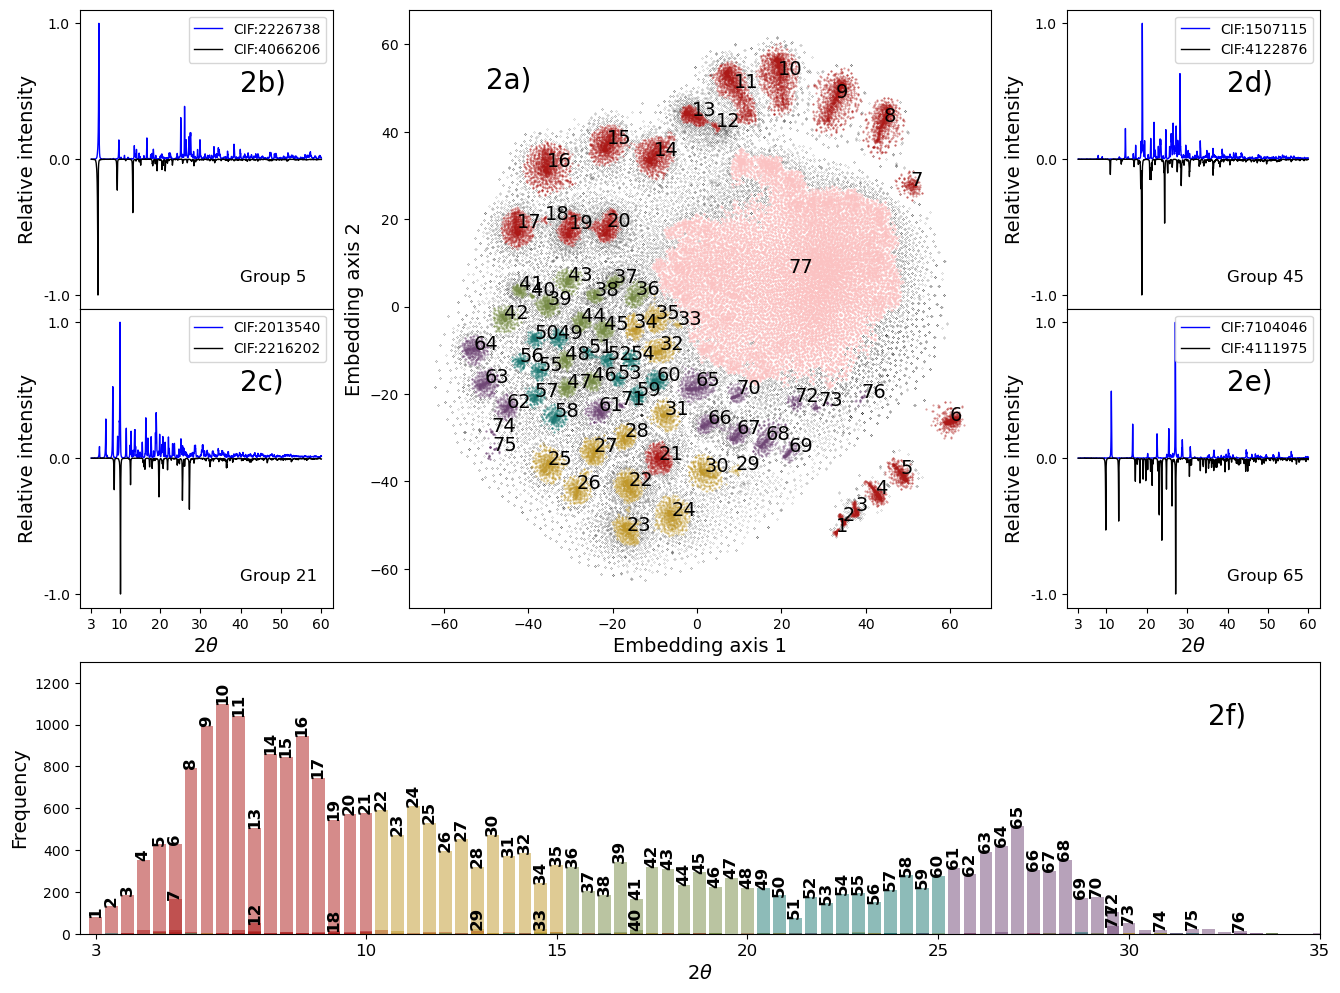

In [7]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 4, wspace=0.3)

ax_mid = plt.subplot(gs[:2,1:3])
ax_bottom = plt.subplot(gs[2,:])

gs_left = gs[0:2,0].subgridspec(2,1, hspace=0)
ax_ltop = plt.subplot(gs_left[0])
ax_lbottom = plt.subplot(gs_left[1], sharex = ax_ltop, sharey = ax_ltop)

gs_right = gs[0:2, 3].subgridspec(2,1,hspace=0)
ax_rtop = plt.subplot(gs_right[0])
ax_rbottom = plt.subplot(gs_right[1], sharex = ax_rtop, sharey=ax_rtop)

color_diccio = dict()
for lab in np.unique(dbscan_diccio[80][20].labels_):
    idxs = np.argwhere(dbscan_diccio[80][20].labels_ == lab)[:,0]
    
    if lab != -1:
        if lab != 51:
            ax_mid.scatter(tsne_diccio[80].embedding_[idxs,0], 
                          tsne_diccio[80].embedding_[idxs,1], s=0.2, alpha=0.5, color=palette[tt_range[lab]])
            ax_mid.annotate(text=f"{new_labels[lab]}", xy = tsne_diccio[80].embedding_[idxs].mean(axis=0), fontsize=14)

        else:
            ax_mid.scatter(tsne_diccio[80].embedding_[idxs,0], 
                          tsne_diccio[80].embedding_[idxs,1], s=0.2, color='#FBC2C2')
            ax_mid.annotate(text=f"{new_labels[lab]}", xy = tsne_diccio[80].embedding_[idxs].mean(axis=0), fontsize=14)
          
    else:
        scatter = ax_mid.scatter(tsne_diccio[80].embedding_[idxs,0], 
                              tsne_diccio[80].embedding_[idxs,1], s=0.01, color='black')

ax_mid.set_xlabel('Embedding axis 1', fontsize=14)    
ax_mid.set_ylabel('Embedding axis 2', fontsize=14)   
ax_mid.annotate(text='2a)', xy=(-50,50), fontsize=20)
idxs_plot = [np.argmin(abs(np.linspace(3,60,139) - tt)) for tt in [3,10,15,20,25,30,35]]


histbars = list()
for label in np.unique(dbscan.labels_):

    if label not in [-1,51]:
     
        unique_counts = np.unique(sxrd[dbscan.labels_ == label].argmax(axis=-1), return_counts=True)
        xtext = unique_counts[0][unique_counts[1].argmax()]
        ytext = unique_counts[1].max()
        
        histbars += [[label, np.linspace(3,60,139, endpoint=False)[xtext]]]
        ax_bottom.bar(unique_counts[0], unique_counts[1], color=palette[tt_range[label]], alpha=0.5)
        ax_bottom.annotate(text=str(new_labels[label]), xy=(xtext-0.5, ytext+10), 
                           fontsize=12, rotation=90, fontweight='bold')

ax_bottom.set_xticks(idxs_plot, np.round(np.linspace(3,60,139),0)[idxs_plot].astype(int), rotation=0, fontsize=12)
ax_bottom.set_xlim(-1,77)
ax_bottom.set_ylim(0,1300)
ax_bottom.set_xlabel(r'$2\theta$', fontsize=14)
ax_bottom.set_ylabel('Frequency', fontsize=14)
ax_bottom.annotate(text='2f)', xy=(70,1000), fontsize=20)

idxs_plot = [np.argmin(abs(np.linspace(3,60,2780) - tt)) for tt in [3,10,20,30,40,50,60]]


ax_ltop.plot(xrd[ulabels == 0][0,:,0], linewidth=1, color='blue', 
             label = f"CIF:{cif_test[ulabels == 1][0]}")
ax_ltop.plot(-xrd[ulabels == 0][1,:,0], linewidth=1, color='black', 
             label = f"CIF:{cif_test[ulabels == 1][1]}")
ax_ltop.annotate(text=f"Group {new_labels[0]}", xy=(1800,-0.9), fontsize=12)
ax_ltop.annotate(text=f"2b)", xy=(1800, 0.5), fontsize=20)

ax_ltop.set_xticks(np.arange(2780)[idxs_plot], 
                      np.round(np.linspace(3,60,2780)[idxs_plot],0).astype(int))
ax_ltop.set_yticks([-1.0,0.0,1.0],[-1.0,0.0,1.0])
ax_ltop.set_ylabel('Relative intensity', fontsize=14)
ax_ltop.legend(loc='best')


ax_lbottom.plot(xrd[ulabels == 35][0,:,0], linewidth=1, 
                color='blue', label = f"CIF:{cif_test[ulabels == 36][0]}")
ax_lbottom.plot(-xrd[ulabels == 35][1,:,0], linewidth=1, 
                color='black', label = f"CIF:{cif_test[ulabels == 36][1]}")
ax_lbottom.annotate(text=f"Group {new_labels[35]}", xy=(1800,-0.9), fontsize=12)
ax_lbottom.annotate(text=f"2c)", xy=(1800, 0.5), fontsize=20)

ax_lbottom.set_xticks(np.arange(2780)[idxs_plot], 
                      np.round(np.linspace(3,60,2780)[idxs_plot],0).astype(int))
ax_lbottom.set_yticks([-1.0,0.0,1.0],[-1.0,0.0,1.0])
ax_lbottom.set_xlabel(r'2$\theta$', fontsize=14)
ax_lbottom.set_ylabel('Relative intensity', fontsize=14)
ax_lbottom.legend(loc='best')

ax_rtop.plot(xrd[ulabels == 71][0,:,0], linewidth=1, color='blue', label = f"CIF:{cif_test[ulabels == 72][0]}")
ax_rtop.plot(-xrd[ulabels == 71][1,:,0], linewidth=1, color='black', label = f"CIF:{cif_test[ulabels == 72][1]}")
ax_rtop.annotate(text=f"Group {new_labels[71]}", xy=(1800,-0.9), fontsize=12)
ax_rtop.annotate(text=f"2d)", xy=(1800, 0.5), fontsize=20)

ax_rtop.set_xticks(np.arange(2780)[idxs_plot], 
                      np.round(np.linspace(3,60,2780)[idxs_plot],0).astype(int))
ax_rtop.set_yticks([-1.0,0.0,1.0],[-1.0,0.0,1.0])

ax_rtop.set_ylabel('Relative intensity', fontsize=14)
ax_rtop.legend(loc='best')

ax_rbottom.plot(xrd[ulabels == 43][0,:,0], linewidth=1, color='blue', label = f"CIF:{cif_test[ulabels == 44][0]}")
ax_rbottom.plot(-xrd[ulabels == 43][1,:,0], linewidth=1, color='black', label = f"CIF:{cif_test[ulabels == 44][1]}")
ax_rbottom.annotate(text=f"Group {new_labels[43]}", xy=(1800,-0.9), fontsize=12)
ax_rbottom.annotate(text=f"2e)", xy=(1800, 0.5), fontsize=20)

ax_rbottom.set_xticks(np.arange(2780)[idxs_plot], 
                      np.round(np.linspace(3,60,2780)[idxs_plot],0).astype(int))
ax_rbottom.set_yticks([-1.0,0.0,1.0],[-1.0,0.0,1.0])
ax_rbottom.set_xlabel(r'2$\theta$', fontsize=14)
ax_rbottom.set_ylabel('Relative intensity', fontsize=14)
ax_rbottom.legend(loc='best')

plt.setp(ax_ltop.get_xticklabels(), visible=False)
plt.setp(ax_rtop.get_xticklabels(), visible=False)

plt.savefig('figure1/Fig1.png', dpi=1200, transparent=True)
plt.show()

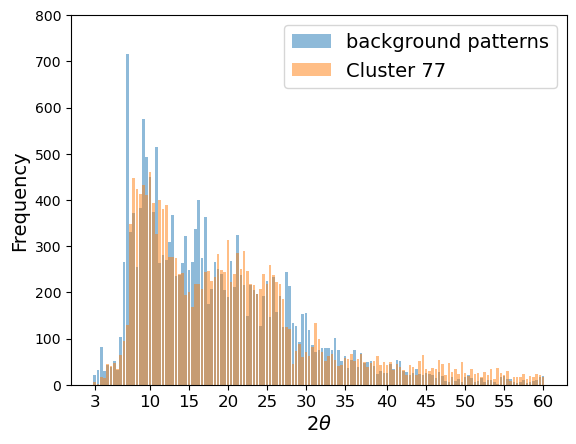

In [8]:
diccio_labels = {-1:'background patterns', 51:'Cluster 77'}
idxs_plot = [np.argmin(abs(np.linspace(3,60,139) - tt)) for tt in [3,10,15,20,25,30,35,40,45,50,55,60]]
plt.figure()
for label in np.unique(dbscan.labels_):

    if label in [-1,51]:
     
        unique_counts = np.unique(sxrd[dbscan.labels_ == label].argmax(axis=-1), return_counts=True)
        xtext = unique_counts[0][unique_counts[1].argmax()]
        ytext = unique_counts[1].max()
        
        plt.bar(unique_counts[0], unique_counts[1], alpha=0.5, label=diccio_labels[label])
        
plt.xticks(idxs_plot, np.round(np.linspace(3,60,139),0)[idxs_plot].astype(int), rotation=0, fontsize=12)

plt.legend(loc='best', fontsize=14)
plt.ylim(0,800)
plt.xlabel(r'$2\theta$', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.savefig('Histogram_non_grouped.png', dpi=300, transparent=True)
plt.show()